## Project 1 Network Analysis on Facebook Ego Network Data

Data 620 Web Analytics
Brandon Chung 3/14/2026

## Instructions

For your first project, you are asked to

1. Identify and load a network dataset that has some categorical information available for each node.
2. For each of the nodes in the dataset, calculate degree centrality and eigenvector centrality.
3. Compare your centrality measures across your categorical groups.

For example, using the dataset from a study of romantic relationships among high school students in Columbus, Ohio [http://researchnews.osu.edu/archive/chains.htm], you might want to determine if there are any differences in your calculated centrality measures between the two sexes.  You might use a t-test or another statistical measure to support your findings.

You may work in a small group.  Your project should be delivered in an Jupyter Notebook, and posted in GitHub.  Your project is due end of day Monday. You and your team should created a video presentation about your project. You should be ready to present your project in our Meet-up on Thursday.


Using facebook friends list data sourced from the SNAP repository found here:

https://snap.stanford.edu/data/ego-Facebook.html

I loaded three seperate ego networks and their associated features to analyze centrality metrics (degree, betweenness and eigenvector) for differences between the categorical groups gender and number of languages spoken. 

In [99]:
# Importing Libraries

import pandas as pd
import networkx as nx

# Creating function to load data and generate networkx graph

def load_ego_network(base_path, ego_id):
    ego_id = str(ego_id)

    
    # Load edges 
    
    edges_file = f"{base_path}/{ego_id}.edges"
    G = nx.read_edgelist(edges_file, nodetype=int)

    
    # Load feature names
    
    featnames = []
    with open(f"{base_path}/{ego_id}.featnames", "r") as f:
        for line in f:
            idx, name = line.strip().split(" ", 1)
            featnames.append(name)

    
    # Load node features
    
    df_feat = pd.read_csv(f"{base_path}/{ego_id}.feat", sep=" ", header=None)
    df_feat = df_feat.rename(columns={0: "node"})

    # rename attribute columns
    for i, feat in enumerate(featnames):
        df_feat = df_feat.rename(columns={i+1: feat})

    
    # Load ego's own features
    
    df_egofeat = pd.read_csv(f"{base_path}/{ego_id}.egofeat", sep=" ", header=None)
    df_egofeat.columns = featnames

    
    # Attach attributes to graph
    
    for _, row in df_feat.iterrows():
        node = row["node"]
        if node in G.nodes():
            for col in df_feat.columns:
                if col != "node":
                    G.nodes[node][col] = row[col]

    return G, df_feat, df_egofeat

# Loading three ego networks 0, 107, and 348

base_path = r"C:\Users\chung\School\620 Web Analytics\facebook\facebook"

G0, df0, ego0 = load_ego_network(base_path, 0)
G107, df107, ego107 = load_ego_network(base_path, 107)
G348, df348, ego348 = load_ego_network(base_path, 348)


First I created a function to load the features and feature names of each node given for three different ego networks and generate the networkx graphs for each of them. 

In [100]:
# Extracting gender and language for Ego 0

# Identify gender columns
gender_cols_0 = [col for col in df0.columns if col.startswith("gender;")]

# Identify language columns
language_cols_0 = [col for col in df0.columns if col.startswith("languages;")]

# Extract gender 
df0["gender_extracted"] = df0[gender_cols_0].idxmax(axis=1)

# Count number of languages spoken
df0["num_languages"] = df0[language_cols_0].sum(axis=1)


In [101]:
# Repeating extraction for Ego 107 and 348

gender_cols_107 = [col for col in df107.columns if col.startswith("gender;")]
language_cols_107 = [col for col in df107.columns if col.startswith("languages;")]

df107["gender_extracted"] = df107[gender_cols_107].idxmax(axis=1)
df107["num_languages"] = df107[language_cols_107].sum(axis=1)

gender_cols_348 = [col for col in df348.columns if col.startswith("gender;")]
language_cols_348 = [col for col in df348.columns if col.startswith("languages;")]

df348["gender_extracted"] = df348[gender_cols_348].idxmax(axis=1)
df348["num_languages"] = df348[language_cols_348].sum(axis=1)


Here I have identified the gender and language columns and mutated into the dataframes columns to show each node's gender and number of languages spoken. The extraction is done this way due to the columns being one-hot encoded categorical attributes.

In [102]:
# Compute Centrality Metrics For Nodes on Each of the Egos

df0["degree_centrality"] = df0["node"].map(nx.degree_centrality(G0))
df0["betweenness_centrality"] = df0["node"].map(nx.betweenness_centrality(G0))
df0["eigenvector_centrality"] = df0["node"].map(
    nx.eigenvector_centrality(G0, max_iter=1000)
)


df107["degree_centrality"] = df107["node"].map(nx.degree_centrality(G107))
df107["betweenness_centrality"] = df107["node"].map(nx.betweenness_centrality(G107))
df107["eigenvector_centrality"] = df107["node"].map(
    nx.eigenvector_centrality(G107, max_iter=1000)
)


df348["degree_centrality"] = df348["node"].map(nx.degree_centrality(G348))
df348["betweenness_centrality"] = df348["node"].map(nx.betweenness_centrality(G348))
df348["eigenvector_centrality"] = df348["node"].map(
    nx.eigenvector_centrality(G348, max_iter=1000)
)


Here I have calculated the degree, betweeness, and eigenvector centrality metrics for each of the nodes in each of the ego networks and mutated the results into their corresponding dataframes.

In [103]:
# Merging dataframes for visualization

df0["ego_id"] = 0
df107["ego_id"] = 107
df348["ego_id"] = 348

df_all = pd.concat([df0, df107, df348], ignore_index=True)


The merged dataframe df_all will be used for visualization purposes only due to the fact that each ego network is its own seperate network. Centrality metrics cannot be cross compared between networks because, centrality scales differ from each ego network due to the differing sizes of the networks.

In [104]:
# Cleaning merged dataframe

# Keeping only necessary columns
df_all = df_all[[
    "gender_extracted",
    "num_languages",
    "degree_centrality",
    "betweenness_centrality",
    "eigenvector_centrality",
    "ego_id"
]]

# Renaming anonymized gender features
unique_genders = df_all["gender_extracted"].unique()

gender_map = {
    unique_genders[0]: "gender_1",
    unique_genders[1]: "gender_2"
}

df_all["gender_extracted"] = df_all["gender_extracted"].map(gender_map)

# Converting gender to categorical type
df_all["gender_extracted"] = df_all["gender_extracted"].astype("category")

# Converting num_languages

df_all["num_languages_cat"] = df_all["num_languages"].map({
    0: "no data",
    1: "1",
    2: "2",
    3: "3",
    4: "4"
}).astype("category")


df_all.head()

,gender_extracted,num_languages,degree_centrality,betweenness_centrality,eigenvector_centrality,ego_id,num_languages_cat
0,gender_1,0,0.048193,0.004335,0.021892,0,no data
1,gender_2,2,0.027108,0.000177,0.000002,0,2
2,gender_2,1,0.048193,0.005137,0.047858,0,1
3,gender_2,0,0.027108,0.011466,0.000029,0,no data
4,gender_2,0,0.036145,0.008219,0.016386,0,no data


Clearning the merged dataframe, df_all, by removing unnecceessary columns, and converting the gender and number of languages spoken columns to categorical variables. Something of note here is that number of languages spoken included 0, which I interpreted as no language data available on the person's facebook account. 

#### Visualizations: Centrality metrics by gender

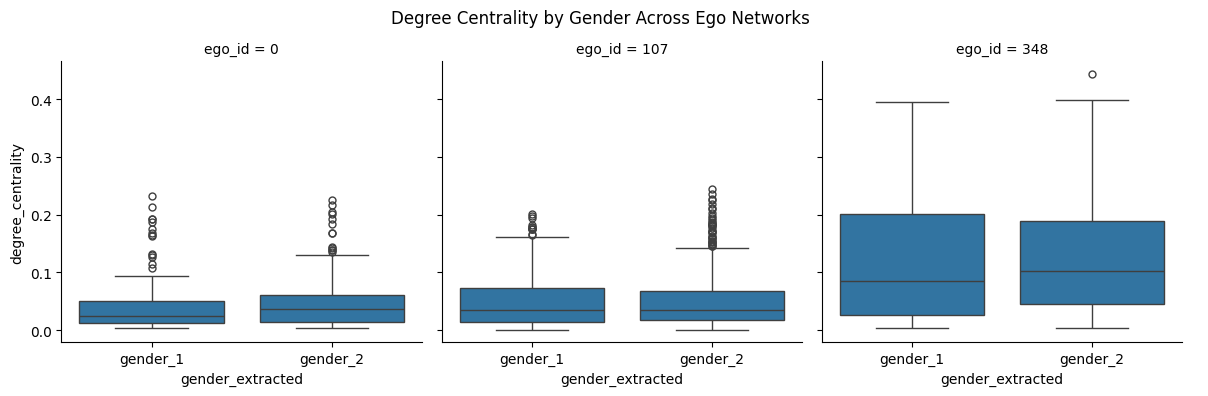

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=df_all,
    x="gender_extracted",
    y="degree_centrality",
    col="ego_id",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Degree Centrality by Gender Across Ego Networks")
plt.show()


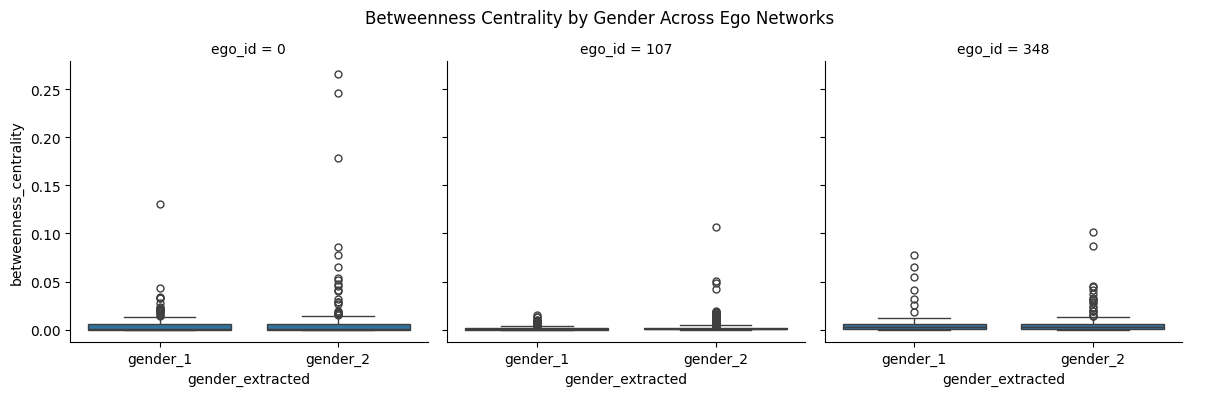

In [106]:
sns.catplot(
    data=df_all,
    x="gender_extracted",
    y="betweenness_centrality",
    col="ego_id",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Betweenness Centrality by Gender Across Ego Networks")
plt.show()


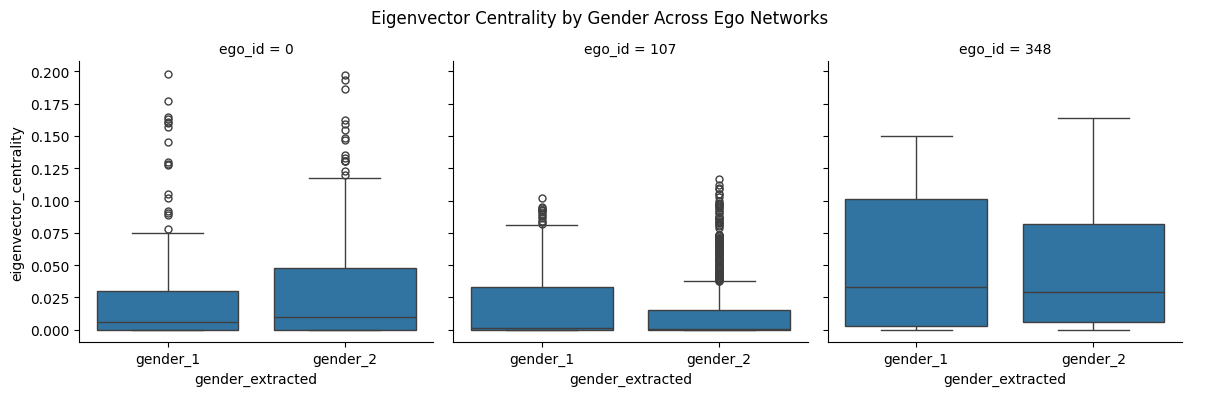

In [107]:
sns.catplot(
    data=df_all,
    x="gender_extracted",
    y="eigenvector_centrality",
    col="ego_id",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Eigenvector Centrality by Gender Across Ego Networks")
plt.show()



From the box plots of our centrality metrics we can see that for degree centrality there does not seem to be a gender difference, however ego id 348's network has a greater spread of IQR. Betweenness centrality viewed by gender seems to show that some nodes of gender 2 display the tendency to have a greater outlier potential. The eigenvector centrality metric viewed by gender does not seem to show a correlation to gender in any of our three ego networks.

#### Visualizations: Centrality Metrics by Languages Spoken

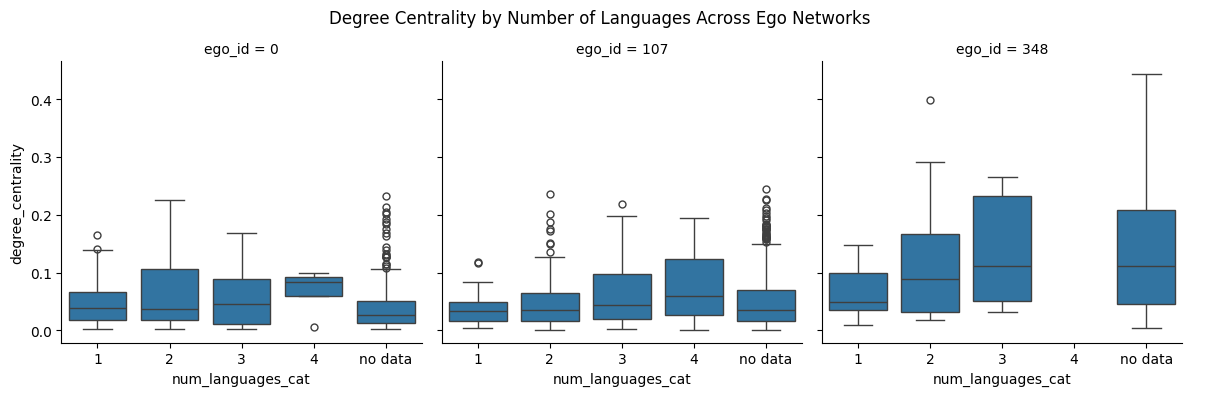

In [108]:
sns.catplot(
    data=df_all,
    x="num_languages_cat",
    y="degree_centrality",
    col="ego_id",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Degree Centrality by Number of Languages Across Ego Networks")
plt.show()


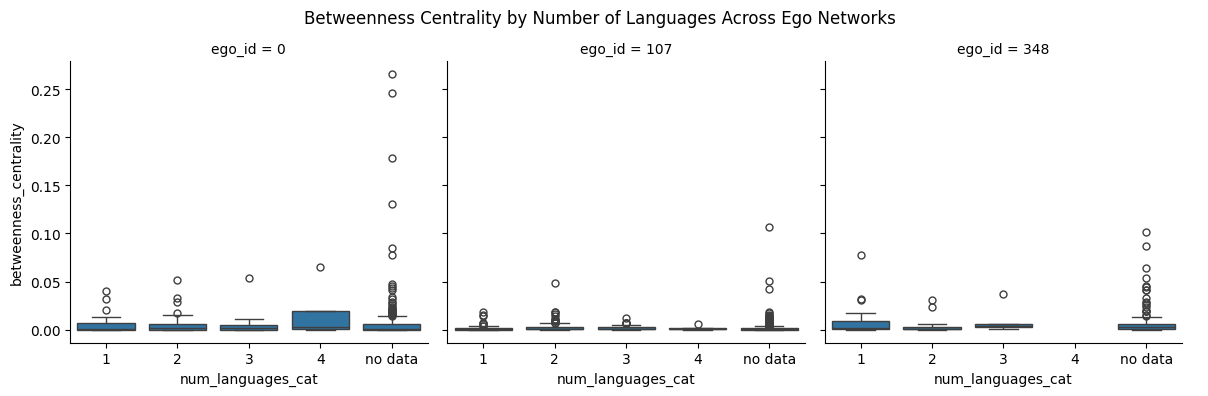

In [109]:
sns.catplot(
    data=df_all,
    x="num_languages_cat",
    y="betweenness_centrality",
    col="ego_id",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Betweenness Centrality by Number of Languages Across Ego Networks")
plt.show()


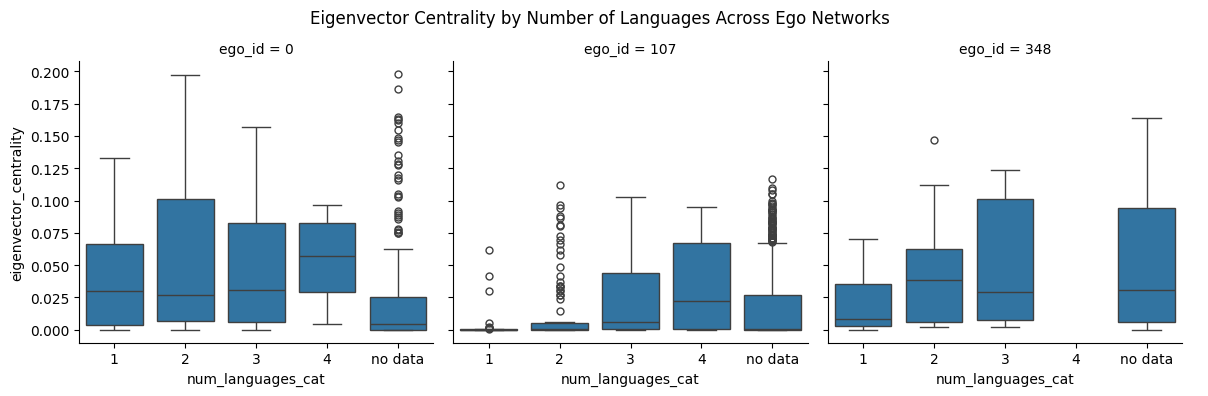

In [110]:
sns.catplot(
    data=df_all,
    x="num_languages_cat",
    y="eigenvector_centrality",
    col="ego_id",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Eigenvector Centrality by Number of Languages Across Ego Networks")
plt.show()


#### Statistical Testing for Differences in Centrality Metrics

In [111]:
# Statistically testing via Mann Whitney U for differences in centrality metrics between genders

from scipy.stats import mannwhitneyu

# Removing rows with NaN centrality metrics

df_clean = df_all.dropna(subset=[
    "degree_centrality",
    "betweenness_centrality",
    "eigenvector_centrality"
])


for ego in df_clean["ego_id"].unique():
    df_ego = df_clean[df_clean["ego_id"] == ego]
    
    g1 = df_ego[df_ego["gender_extracted"] == "gender_1"]
    g2 = df_ego[df_ego["gender_extracted"] == "gender_2"]
    
    u_deg, p_deg = mannwhitneyu(g1["degree_centrality"], g2["degree_centrality"])
    u_bet, p_bet = mannwhitneyu(g1["betweenness_centrality"], g2["betweenness_centrality"])
    u_eig, p_eig = mannwhitneyu(g1["eigenvector_centrality"], g2["eigenvector_centrality"])
    
    print(f"Ego {ego}:")
    print("  Degree p =", p_deg)
    print("  Betweenness p =", p_bet)
    print("  Eigenvector p =", p_eig)
    print()


Ego 0:
  Degree p = 0.09607815343381974
  Betweenness p = 0.38147004673950313
  Eigenvector p = 0.08693155582882911

Ego 107:
  Degree p = 0.7530692219308052
  Betweenness p = 0.0013596496127823013
  Eigenvector p = 0.0010131343773771085

Ego 348:
  Degree p = 0.4741200227383455
  Betweenness p = 0.4801830896976681
  Eigenvector p = 0.9284807355643303



Nodes with undefined centrality values (isolated nodes or nodes outside the connected component) were removed prior to statistical testing.

Gender differences in centrality metrics were not consistant across ego networks. Ego 0 and 348 showed no significant differences in degree, betweenness, or eigenvector centrality. However in Ego 107 gender groups differed significantly in betweenness and eigenvector centrality, suggesting that one gender occupies more influential or well-connected positions in that network.

In [112]:
# Statistically testing via Kruskal Wallis for differences in centrality metrics between numbers of languages spoken 

from scipy.stats import kruskal

for ego in df_clean["ego_id"].unique():
    df_ego = df_clean[df_clean["ego_id"] == ego]

    print(f"\nEgo {ego}")


    degree_groups = [
        df_ego[df_ego["num_languages_cat"] == lang]["degree_centrality"].dropna()
        for lang in df_ego["num_languages_cat"].unique()
    ]

    degree_groups = [g for g in degree_groups if len(g) > 1]

    if len(degree_groups) < 2:
        print("  Degree: Not enough valid groups for testing.")
    else:
        h_deg, p_deg = kruskal(*degree_groups)
        print("  Degree p =", p_deg)


    bet_groups = [
        df_ego[df_ego["num_languages_cat"] == lang]["betweenness_centrality"].dropna()
        for lang in df_ego["num_languages_cat"].unique()
    ]

    bet_groups = [g for g in bet_groups if len(g) > 1]

    if len(bet_groups) < 2:
        print("  Betweenness: Not enough valid groups for testing.")
    else:
        h_bet, p_bet = kruskal(*bet_groups)
        print("  Betweenness p =", p_bet)


    eig_groups = [
        df_ego[df_ego["num_languages_cat"] == lang]["eigenvector_centrality"].dropna()
        for lang in df_ego["num_languages_cat"].unique()
    ]

    eig_groups = [g for g in eig_groups if len(g) > 1]

    if len(eig_groups) < 2:
        print("  Eigenvector: Not enough valid groups for testing.")
    else:
        h_eig, p_eig = kruskal(*eig_groups)
        print("  Eigenvector p =", p_eig)



Ego 0
  Degree p = 0.08738186452858972
  Betweenness p = 0.4500718196163894
  Eigenvector p = 0.00012402055799205121

Ego 107
  Degree p = 0.16723003878817427
  Betweenness p = 0.005219217019128543
  Eigenvector p = 1.9101689918149724e-07

Ego 348
  Degree p = 0.12016736436506638
  Betweenness p = 0.3868700134011889
  Eigenvector p = 0.20876332242945278


Kruskal–Wallis tests revealed that the relationship between number of languages spoken and centrality varied across ego networks. In Ego 0, language groups differed significantly in eigenvector centrality (p < .001), but not in degree or betweenness centrality. In Ego 107, significant differences emerged for both betweenness (p < .01) and eigenvector centrality (p < .001), indicating that multilingual individuals occupy more influential or brokerage‑like positions in this network. No significant differences across language groups were observed in Ego 348 for any centrality metric


#### Conclusion


In [113]:
# Gender test results (Mann–Whitney U)
gender_results = {
    ("Ego 0", "Degree"): 0.09607815343381974,
    ("Ego 0", "Betweenness"): 0.38147004673950313,
    ("Ego 0", "Eigenvector"): 0.08693155582882911,

    ("Ego 107", "Degree"): 0.7530692219308052,
    ("Ego 107", "Betweenness"): 0.0013596496127823013,
    ("Ego 107", "Eigenvector"): 0.0010131343773771085,

    ("Ego 348", "Degree"): 0.4741200227383455,
    ("Ego 348", "Betweenness"): 0.4801830896976681,
    ("Ego 348", "Eigenvector"): 0.9284807355643303,
}

# Language test results (Kruskal–Wallis)
language_results = {
    ("Ego 0", "Degree"): 0.08738186452858972,
    ("Ego 0", "Betweenness"): 0.4500718196163894,
    ("Ego 0", "Eigenvector"): 0.00012402055799205121,

    ("Ego 107", "Degree"): 0.16723003878817427,
    ("Ego 107", "Betweenness"): 0.005219217019128543,
    ("Ego 107", "Eigenvector"): 1.9101689918149724e-07,

    ("Ego 348", "Degree"): 0.12016736436506638,
    ("Ego 348", "Betweenness"): 0.3868700134011889,
    ("Ego 348", "Eigenvector"): 0.20876332242945278,
}

# Summary Table
rows = []
for (ego, metric), gender_p in gender_results.items():
    lang_p = language_results[(ego, metric)]
    rows.append([ego, metric, gender_p, lang_p])

summary_df = pd.DataFrame(rows, columns=[
    "Ego Network", "Centrality Metric",
    "Gender (Mann–Whitney p)",
    "Languages (Kruskal–Wallis p)"
])

summary_df


,Ego Network,Centrality Metric,Gender (Mann–Whitney p),Languages (Kruskal–Wallis p)
0,Ego 0,Degree,0.096078,8.738186e-02
1,Ego 0,Betweenness,0.381470,4.500718e-01
2,Ego 0,Eigenvector,0.086932,1.240206e-04
3,Ego 107,Degree,0.753069,1.672300e-01
4,Ego 107,Betweenness,0.001360,5.219217e-03
5,Ego 107,Eigenvector,0.001013,1.910169e-07
6,Ego 348,Degree,0.474120,1.201674e-01
7,Ego 348,Betweenness,0.480183,3.868700e-01
8,Ego 348,Eigenvector,0.928481,2.087633e-01


Across the three ego networks, the relationship between the degree, betweenness, and eigenvector centrality metrics and our gender and language variables varied, revealing that structural patterns likely depend on the specific social context of each ego network. Gender differences were largely absent in Ego 0 and Ego 348, with no significant variation in degree, betweenness, or eigenvector centrality. In contrast, Ego 107 showed clear gender-based differences in betweenness and eigenvector centrality, indicating that one gender occupies more influential positions in this network.

A similar pattern showed with languages spoken. Ego 348 showed no significant differences across language groups for any centrality metric, suggesting that speaking multiple languages did not correspond to structural variation in this network. Ego 0 exhibited significant differences only in eigenvector centrality, implying that multilingual individuals in this network tend to be embedded within more influential neighborhoods. Ego 107 again displayed the strongest effects, with significant differences in both betweenness and eigenvector centrality across language groups. This suggests that multilingual individuals in Ego 107 are more likely to act as bridges between subgroups and to be connected to other highly central individuals.

Taken together, these findings demonstrate that neither gender nor multilingualism exerts broad effects across networks. Instead, their influence on centrality is likely highly context‑dependent, emerging strongly in some ego networks while remaining absent in others. This highlights the importance of analyzing individual networks rather than assuming consistent structural patterns across social contexts.


Video Presentation: https://youtu.be/yNRn8k6ahco